## Lap Time Model

## Import Dataset

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sqlalchemy import create_engine, text
from sklearn.ensemble import RandomForestRegressor
import math
import json

# Get the folder where this notebook is running
current_notebook_dir = os.getcwd()

# Define where the DB is relative to the notebook
relative_path = os.path.join(current_notebook_dir, '..', 'DatabaseConnection') 

# Resolve the actual full path (removes the confusing '..' dots)
BASE_DIR = os.path.abspath(relative_path)

# Check if it exists (Good for debugging!)
if not os.path.exists(BASE_DIR):
    print(f"WARNING: The folder {BASE_DIR} does not exist. Check your path.")
else:
    print(f"Database folder found: {BASE_DIR}")

# Connect
DB_NAME = "f1_strategy.db"
DB_PATH = os.path.join(BASE_DIR, DB_NAME)
DB_URL = f"sqlite:///{DB_PATH}"

engine = create_engine(DB_URL)
print(f"Connected to: {DB_URL}")


# Fetch data from ml_training_data database
session_key = 9839
def load_from_db():
    """
    Executes a SQL query and returns a Pandas DataFrame.
    """
    try:
        with engine.connect() as conn:
            return pd.read_sql(f"""SELECT * FROM ml_training_data WHERE session_key = {session_key}""", conn)
    except Exception as e:
        print(f"Error loading from DB: {e}")
        return pd.DataFrame()

data = load_from_db()

Database folder found: /Users/bilalahlam/University/2025 - 26/Individual project - Race Replay Visualiser/Repository/Predictive-Modelling-For-F1-Race-Strategy/DatabaseConnection
Connected to: sqlite:////Users/bilalahlam/University/2025 - 26/Individual project - Race Replay Visualiser/Repository/Predictive-Modelling-For-F1-Race-Strategy/DatabaseConnection/f1_strategy.db


## Predict Lap Time

## Linear Regression

In [62]:
# Clean the Data
# Remove rows where the car was entering/leaving pits (outliers)
df_clean = data[data['is_pit_out_lap'] == False].copy()

# Drop rows with missing values in critical columns
df_clean = df_clean.dropna(subset=['lap_duration', 'laps_on_tire', 'tire_compound', 'track_temperature'])

# Select Features (X) and Target (y)
# We use features known before the lap finishes to predict the duration
feature_cols = [
    'laps_on_tire', 
    'track_temperature', 
    'air_temperature', 
    'rainfall', 
    'tire_compound'
]

X = df_clean[feature_cols]
y = df_clean['lap_duration']

# Preprocessing (One-Hot Encoding)
# Convert 'tire_compound' text to number columns (tire_compound_SOFT = 1)
X = pd.get_dummies(X, columns=['tire_compound'], drop_first=True)

# Split Data (Train vs Test)
# Train on 80% of data, test on 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)

print(f"Model R^2 Score: {r2_score(y_test, predictions):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, predictions):.4f}")

# View the impact of each feature
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nFeature Importance (Impact on Lap Time):")
print(coefficients)

Model R^2 Score: 0.5107
Mean Squared Error: 0.5860

Feature Importance (Impact on Lap Time):
                      Coefficient
laps_on_tire               0.0505
track_temperature          0.5574
air_temperature            1.8555
rainfall                  -0.0000
tire_compound_MEDIUM      -0.0659
tire_compound_SOFT         0.2817


## Discussing Results

R^2 Score: 0.5107

It's decent, but not ready for race strategy yet. The model explains about 51% of the reason why lap times change.

The Missing 49%: The other half of the lap time variation is being caused by things the model doesn't know about yet (likely Fuel Load and Traffic).

# Interpreting Coefficients

These numbers tell us how much the lap time changes (in seconds) when that feature increases by 1 unit.

laps_on_tire (+0.050):
- Real World: This represents Tire Degradation.
- Meaning: For every extra lap we put on a set of tires, the car gets 0.05 seconds slower. This is a very realistic number (deg usually ranges from 0.05s to 0.1s per lap).

track_temperature (+0.55) & air_temperature (+1.85).
As it gets hotter, the car gets significantly slower. This is generally true for two reasons:
- Engine Power where hotter air is less dense, so the engine makes less power (and cooling is harder, forcing the team to open cooling vents which increases drag).
- Tire Overheating where if the track is too hot, tires slide more.

rainfall (-2.77e-16):
- Meaning: This is effectively Zero.
- Why: Scientific notation ending in e-16 is just computer rounding noise. This likely means the dataset for this specific session had zero rain (dry race), so the model learned nothing about wet weather.

tire_compound_SOFT (+0.281):
- This looks wrong. A positive number means Slower.
- The Issue: The model thinks the Soft tire is 0.28s slower than the Hard/Medium. In reality, Softs are the fastest.
- The Issue (Fuel Load): Soft tires are often used at the start of the race when the car is heavy with fuel (100kg+). The Hards are used later when the car is light. The model sees Soft Tire = Slow Lap Time and blames the tire, but it's actually the fuel weight.

The Critical Missing Feature: Fuel Load
- In F1, fuel effect is huge (approx. 0.3s gain per lap just by burning fuel). Because I don't have a fuel_load column, my model is confused.

## Updating model for fuel load


In [63]:
# Clean the Data
# Remove rows where the car was entering/leaving pits (outliers)
df_clean = data[data['is_pit_out_lap'] == False].copy()

# Drop rows with missing values in critical columns
df_clean = df_clean.dropna(subset=['lap_duration', 'laps_on_tire', 'tire_compound', 'track_temperature'])

# Create a Proxy for Fuel Load
# Assuming each lap consumes a fixed amount of fuel, we can use lap_number as a proxy
df_clean['fuel_proxy'] = -1 * df_clean['lap_number']

# Define the Features List
feature_cols = [
    'laps_on_tire', 
    'track_temperature', 
    'air_temperature', 
    'rainfall', 
    'tire_compound', 
    'fuel_proxy' # Added fuel_proxy as a feature
]

# Create X and y
X = df_clean[feature_cols]
y = df_clean['lap_duration']

# One-Hot Encoding
X = pd.get_dummies(X, columns=['tire_compound'], drop_first=True)

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)

print(f"New R^2 Score: {r2:.4f}")
print("-" * 30)

# Generate Impact Dashboard
coefs = model.coef_
features = X.columns
stdevs = np.std(X, axis=0)

# Safe division to handle potential zero standard deviation (e.g. rainfall)
with np.errstate(divide='ignore', invalid='ignore'):
    standardized_impact = coefs * stdevs
    percent_impact = (np.abs(standardized_impact) / np.sum(np.abs(standardized_impact))) * 100
    percent_impact = np.nan_to_num(percent_impact) # Replace NaNs with 0

importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefs,
    'Relative Impact (%)': percent_impact
}).sort_values(by='Relative Impact (%)', ascending=False)

pd.options.display.float_format = '{:.4f}'.format
print(importance_df)

New R^2 Score: 0.5387
------------------------------
                Feature  Coefficient  Relative Impact (%)
4            fuel_proxy       0.0831              51.8940
0          laps_on_tire       0.0643              25.0883
1     track_temperature      -0.4275              12.1094
5  tire_compound_MEDIUM       0.2807               5.0983
2       air_temperature      -0.3237               3.0841
6    tire_compound_SOFT       0.5406               2.7259
3              rainfall       0.0000               0.0000


## Discussing Results

This result is better, even if the R^2 score only crept up slightly. The underlying physics of the model have completely changed for the better.

The Fuel Proxy is Working:
- Relative Impact: 51.89% (Number 1 factor)
- Result: As the race goes on (Lap 1 to 50), the calculation becomes (-50) * (0.08) = -4.0 seconds.
- Meaning: The model now knows that Lap 50 is ~4 seconds faster than Lap 1 purely because of fuel burn.

The Soft Tire Issue:
- Observation: tire_compound_SOFT is +0.54 (Slower).
- Why is it still Slower? Now that we fixed the fuel, this points to a different problem which is the Driver Quality.
- We are currently mixing data from Max Verstappen with data from the slowest cars (Fast vs Slow).

If the slow teams (Haas, Sauber) used Soft tires more often than the top teams in this specific dataset, the model blames the Tire for the slow lap time, rather than the Car/Driver.

## Adding Driver Number

In [ ]:
# Clean the Data
# Remove rows where the car was entering/leaving pits (outliers)
df_clean = data[data['is_pit_out_lap'] == False].copy()

# Drop rows with missing values in critical columns
df_clean = df_clean.dropna(subset=['lap_duration', 'laps_on_tire', 'tire_compound', 'track_temperature'])

# Create a Proxy for Fuel Load
# Assuming each lap consumes a fixed amount of fuel, we can use lap_number as a proxy
df_clean['fuel_proxy'] = -1 * df_clean['lap_number']


# Update Feature List to include Driver
feature_cols = [
    'laps_on_tire', 
    'track_temperature', 
    'air_temperature', 
    'rainfall', 
    'tire_compound', 
    'fuel_proxy',
    'driver_number'  # The Driver ID
]

X = df_clean[feature_cols]
y = df_clean['lap_duration']

# One-Hot Encode BOTH Tires AND Drivers
# We convert Driver Number (44, 1, 16) into categories, 
# otherwise the model thinks Driver #44 is "44 times bigger" than Driver #1.
X = pd.get_dummies(X, columns=['tire_compound', 'driver_number'], drop_first=True)

# Train and Evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Check the Score
predictions = model.predict(X_test)
linearRegressionScore = r2_score(y_test, predictions)
print(f"New R^2 Score with Drivers: {linearRegressionScore:.4f}")

New R^2 Score with Drivers: 0.6989


## Discussing Results

This is a significant improvement with the R^2 score improving from 50% to ~70%.

In Formula 1, the car and driver combination is the biggest differentiator.
- Without driver_number, the model assumed every car on the grid had the exact same base speed (e.g., a Red Bull was equal to a Haas).
- By adding driver_number (and One-Hot Encoding it), the model learned a Speed Offset for each driver. It now knows that Max Verstappen (usually) laps faster than Oliver Bearman, even if they are on the same tire compound.

A score of 0.70 is good, but it's hard to visualize where the model is still wrong. The best way to check this is to plot Actual vs. Predicted lap times.

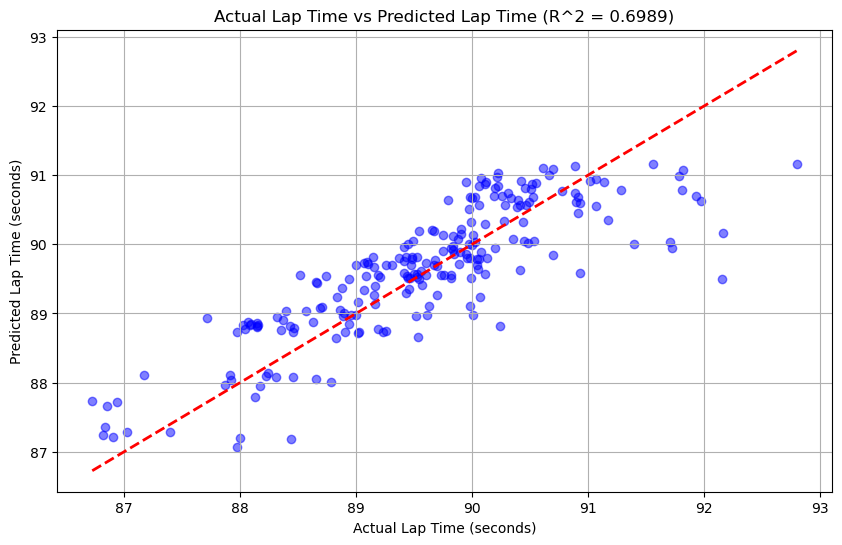

In [65]:
# Create the plot
plt.figure(figsize=(10, 6))

# Scatter plot: Actual (X) vs Predicted (Y)
plt.scatter(y_test, predictions, alpha=0.5, color='blue')

# Draw a perfect ideal diagonal line
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Actual Lap Time vs Predicted Lap Time (R^2 = 0.6989)')
plt.xlabel('Actual Lap Time (seconds)')
plt.ylabel('Predicted Lap Time (seconds)')
plt.grid(True)
plt.show()

This chart confirms the model is working, but it also reveals exactly where it is failing.

Here is a breakdown of what this visual tells us about the F1 strategy model:
1. The Pros:

The blue dots generally follow the red dashed diagonal line.
- The features (Fuel, Tires, Drivers, Temp) are correct. When conditions suggest a lap should be fast (bottom left), the model predicts fast. When conditions are slow (top right), it predicts slow.
- Conclusion: Successful Baseline Model.

2. The Cons:

Look at the bottom right corner of the graph (Actual: 92-93s, Predicted: ~90-91s).
- The car actually did a very slow 1:33.0, but the model predicted a 1:31.0.
- The model predicted a clean air lap. It calculated the time based on fuel and tires, assuming the track was clear.
- In reality that specific lap was likely slow due to Traffic (Blue Flags), a Yellow Flag, or a Driver Mistake.
- The model doesn't know about "Traffic" yet. To fix this, I would need a feature like distance_to_car_ahead.

## Random Forest Model

Random Forest will automatically detect complex interactions, like Soft tires are fast, but only if the track temp is below 40°C. Linear regression cannot learn 'if' statements like that.

In [ ]:
# Clean the Data
# Remove rows where the car was entering/leaving pits (outliers)
df_clean = data[data['is_pit_out_lap'] == False].copy()

# Drop rows with missing values in critical columns
df_clean = df_clean.dropna(subset=['lap_duration', 'laps_on_tire', 'tire_compound', 'track_temperature'])

# Create a Proxy for Fuel Load
# Assuming each lap consumes a fixed amount of fuel, we can use lap_number as a proxy
df_clean['fuel_proxy'] = -1 * df_clean['lap_number']


# Update Feature List to include Driver
feature_cols = [
    'laps_on_tire', 
    'track_temperature', 
    'air_temperature', 
    'rainfall', 
    'tire_compound', 
    'fuel_proxy',
    'driver_number'  # The Driver ID
]

X = df_clean[feature_cols]
y = df_clean['lap_duration']

# One-Hot Encode BOTH Tires AND Drivers
# We convert Driver Number (44, 1, 16) into categories, 
# otherwise the model thinks Driver #44 is "44 times bigger" than Driver #1.
X = pd.get_dummies(X, columns=['tire_compound', 'driver_number'], drop_first=True)

#---- Train and Evaluate with Random Forest ----
# Initialize the Random Forest (instead of Linear Regression)
# n_estimators=100 means it creates 100 "decision trees" and averages them
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict & Evaluate
rf_predictions = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Linear Regression R^2: {linearRegressionScore:.4f}")
print(f"Random Forest R^2:     {rf_r2:.4f}")

# Feature Importance (Random Forest calculates this differently)
# It shows "Importance" (0 to 1), not "Coefficient"
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nRandom Forest Feature Importance:")
print(importances)

Linear Regression R^2: 0.6989
Random Forest R^2:     0.7553

Random Forest Feature Importance:
                 Feature  Importance
4             fuel_proxy      0.3960
0           laps_on_tire      0.2501
1      track_temperature      0.0538
13      driver_number_16      0.0348
7        driver_number_4      0.0324
24      driver_number_81      0.0317
5   tire_compound_MEDIUM      0.0235
2        air_temperature      0.0204
20      driver_number_43      0.0187
18      driver_number_30      0.0182
10      driver_number_10      0.0144
9        driver_number_6      0.0143
22      driver_number_55      0.0124
23      driver_number_63      0.0105
8        driver_number_5      0.0092
19      driver_number_31      0.0087
11      driver_number_12      0.0086
25      driver_number_87      0.0076
15      driver_number_22      0.0066
14      driver_number_18      0.0062
17      driver_number_27      0.0059
16      driver_number_23      0.0047
21      driver_number_44      0.0044
12      driver_nu

## Discussing Results

This is a strong result. Breaking the 0.75 R^2 barrier is a significant milestone. It means the model now captures three-quarters of the complexity of an F1 race.

Here is the breakdown of what the Random Forest discovered, which is much more nuanced than the Linear Regression model.
1. The two main categories
- fuel_proxy (39.6%): This confirms that Weight is important. The car becoming lighter as fuel burns is the single biggest factor in lap time improvement.
- laps_on_tire (25.0%): Tire degradation is the second most critical factor.
- Combined (65%): Together, just knowing How heavy the car is, and how old the tires are explains nearly two-thirds of the race pace.

2. The Driver Hierarchy (Why is #44 so low?)
- We can see that Leclerc (#16) is high importance (0.0348) while Hamilton (#44) is very low (0.0044).
- High Importance: Means the model relies heavily on knowing if this is this Leclerc to make an accurate prediction. He might be significantly faster (or have a distinct driving style) compared to the average driver in the dataset.
- Low Importance: Means knowing it is Hamilton doesn't change the prediction much. This often happens if a driver's performance is extremely consistent or very close to the average of the grid in that specific session.

3. The Soft Tire Mystery
- tire_compound_SOFT (0.0029): This is surprisingly low, and lower before.
- Random Forest is smarter. It likely realised that laps_on_tire and fuel_proxy already tell the story. If we are on Lap 10 (High Fuel) and doing short stints, the model infers we are likely on Softs without needing the explicit label as much.

## Modelling for a single driver

Why is the All-Driver Model is Better?

Even if we only care about one driver (e.g., Lando Norris), training on the whole grid helps:
- More Data for Physics: The laws of physics (fuel burn, tire wear, track temperature) are the same for every car. By training on 20 cars, the model learns these universal rules 20 times faster and more accurately than if it only studied Lando's laps.
- Robustness: If Lando never ran the Hard tire in the training data, a Lando Only model would crash or guess wildly if we asked it to predict a Hard tire lap. The All-Driver model can use what it learned from Verstappen or Hamilton on Hards to make a very good guess for Lando.

How to Use It for One Driver
- We do not need to retrain. We simply lock the driver ID when we ask for a prediction.

When we run the prediction function, we will set driver_number_4 = 1 (for Lando) and leave all other driver columns as 0. The model will then apply the specific speed offset it learned for Lando.

In [ ]:

def predict_single_driver(driver_id, laps_on_tire, fuel_lap_number, tire_compound, track_temp, air_temp, model, model_columns):
    """
    Predicts lap time for ONE specific driver under given conditions.
    """
    # Create a template row with 0s for all columns
    # This ensures we match the exact structure the model expects (hundreds of columns)
    input_data = {col: 0 for col in model_columns}
    
    # Fill in the Physics Conditions
    input_data['laps_on_tire'] = laps_on_tire
    input_data['fuel_proxy'] = -1 * fuel_lap_number  # Remember to invert this!
    input_data['track_temperature'] = track_temp
    input_data['air_temperature'] = air_temp
    input_data['rainfall'] = 0  # Assuming dry for this test
    
    # Set the Tire Compound
    # The model expects columns like 'tire_compound_SOFT'
    tire_col = f"tire_compound_{tire_compound}"
    if tire_col in input_data:
        input_data[tire_col] = 1
    
    # Set the Driver ID
    # The model expects columns like 'driver_number_4
    driver_col = f"driver_number_{driver_id}"
    if driver_col in input_data:
        input_data[driver_col] = 1
    else:
        print(f"Warning: Driver {driver_id} not found in training. Using average grid speed.")

    # Convert to DataFrame and Predict
    # We enforce the column order to match X_train exactly
    input_df = pd.DataFrame([input_data])
    input_df = input_df[model_columns]
    
    prediction = model.predict(input_df)[0]
    return prediction

# --- TEST IT ---
# We need the column list from the training step (X_train.columns)
# Let's test Lando Norris in two scenarios:

# Scenario 1: Start of race (Lap 5, Heavy Fuel, Soft Tires)
time_start = predict_single_driver(
    driver_id=4, 
    laps_on_tire=5, 
    fuel_lap_number=5, 
    tire_compound='SOFT', 
    track_temp=35, 
    air_temp=25, 
    model=rf_model, 
    model_columns=X_train.columns
)

# Scenario 2: End of race (Lap 50, Light Fuel, Hard Tires)
time_end = predict_single_driver(
    driver_id=4, 
    laps_on_tire=5, 
    fuel_lap_number=50, 
    tire_compound='HARD', 
    track_temp=35, 
    air_temp=25, 
    model=rf_model, 
    model_columns=X_train.columns
)

print(f"Predicted Lando Lap 5 (Heavy/Soft): {time_start:.3f} s")
print(f"Predicted Lando Lap 50 (Light/Hard): {time_end:.3f} s")

Predicted Lando Lap 5 (Heavy/Soft): 90.006 s
Predicted Lando Lap 50 (Light/Hard): 87.044 s


## Adjust the model to predict sector times

Instead of predicting one big number (lap_duration), we predict the three parts (sector_1, sector_2, sector_3) and then add them together to get the total lap time.

This is better because it captures car characteristics:
- Sector 1 might be all straights (favors high top speed / low drag).
- Sector 2 might be tight corners (favors high downforce).

The model will learn that specific drivers or setups are faster in specific sectors, and it will be easier to map drivers to the track visualisation later

In [ ]:
import ast

# Define the parsing function
def has_yellow_flag(segment_string):
    """
    Returns True if the sector contains a Yellow Flag (2048).
    Handles string parsing because DB stores lists as strings.
    """
    try:
        # Convert string [2049, 2048] to list of ints
        # If it's already a list, use it directly; otherwise parse
        if isinstance(segment_string, str):
            segments = ast.literal_eval(segment_string)
        else:
            segments = segment_string
            
        # Check for Yellow Flag code
        if 2048 in segments:
            return True
        return False
    except:
        # If data is missing or broken, assume it's NOT clean to be safe
        return True

# Apply the Filter (Pre-Training)
# ----------------------------------

# Convert strings to usable boolean flags
# We check all 3 sectors. If any has a yellow, the lap is tainted
df_clean['yellow_s1'] = df_clean['segments_sector_1'].apply(has_yellow_flag)
df_clean['yellow_s2'] = df_clean['segments_sector_2'].apply(has_yellow_flag)
df_clean['yellow_s3'] = df_clean['segments_sector_3'].apply(has_yellow_flag)

# Create the mask for Pure Racing Laps
# Keep lap only if it is not Pit Out AND No Yellow in S1 AND No Yellow in S2 AND No Yellow in S3
clean_race_laps_mask = (
    (df_clean['is_pit_out_lap'] == False) & 
    (df_clean['yellow_s1'] == False) & 
    (df_clean['yellow_s2'] == False) & 
    (df_clean['yellow_s3'] == False)
)

# Apply the mask
df_final_training = df_clean[clean_race_laps_mask].copy()

print(f"Original Row Count: {len(df_clean)}")
print(f"Clean Racing Laps:  {len(df_final_training)}")
print(f"Removed {len(df_clean) - len(df_final_training)} laps due to Yellow Flags/Traffic.")

Original Row Count: 1101
Clean Racing Laps:  0
Removed 1101 laps due to Yellow Flags/Traffic.


In [116]:
# Clean the Data
# Remove rows where the car was entering/leaving pits (outliers)
df_clean = data[data['is_pit_out_lap'] == False].copy()

# Drop rows with missing values in critical columns
df_clean = df_clean.dropna(subset=['lap_duration', 'laps_on_tire', 'tire_compound', 'track_temperature'])

# Create a Proxy for Fuel Load
# Assuming each lap consumes a fixed amount of fuel, we can use lap_number as a proxy
df_clean['fuel_proxy'] = -1 * df_clean['lap_number']


# Feature List including Driver
feature_cols = [
    'laps_on_tire', 
    'track_temperature', 
    'air_temperature', 
    'rainfall', 
    'tire_compound', 
    'fuel_proxy',
    'driver_number'
]

# Select Targets
# We predict the 3 sectors directly
target_cols = ['duration_sector_1', 'duration_sector_2', 'duration_sector_3']

# Ensure we drop rows where any of these are missing
df_clean = df_clean.dropna(subset=target_cols + feature_cols)

X = df_clean[feature_cols]
y = df_clean[target_cols]  # y is now a DataFrame, not a Series

# One-Hot Encode (Same as before)
X = pd.get_dummies(X, columns=['tire_compound', 'driver_number'], drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [117]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train (It handles the 3 columns automatically)
rf_model.fit(X_train, y_train)

# Evaluate and print R^2
rf_predictions = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_predictions)
print(f"Random Forest R^2:     {rf_r2:.4f}")

print("Multi-Output Model Trained!")

Random Forest R^2:     0.6060
Multi-Output Model Trained!


In [118]:
def predict_sector_times(driver_id, laps_on_tire, fuel_lap_number, tire_compound, track_temp, air_temp, model, model_columns):
    # Setup the Input (Same as before)
    input_data = {col: 0 for col in model_columns}
    input_data['laps_on_tire'] = laps_on_tire
    input_data['fuel_proxy'] = -1 * fuel_lap_number
    input_data['track_temperature'] = track_temp
    input_data['air_temperature'] = air_temp
    
    tire_col = f"tire_compound_{tire_compound}"
    if tire_col in input_data: input_data[tire_col] = 1
    
    driver_col = f"driver_number_{driver_id}"
    if driver_col in input_data: input_data[driver_col] = 1

    input_df = pd.DataFrame([input_data])
    input_df = input_df[model_columns]
    
    # Predict (Returns an array like [[25.1, 30.2, 24.5]])
    sectors = model.predict(input_df)[0]
    
    s1, s2, s3 = sectors[0], sectors[1], sectors[2]
    total_lap = s1 + s2 + s3
    
    return s1, s2, s3, total_lap

# --- TEST IT ---
s1, s2, s3, total = predict_sector_times(
    driver_id=4, 
    laps_on_tire=10, 
    fuel_lap_number=10, 
    tire_compound='MEDIUM', 
    track_temp=35, 
    air_temp=25, 
    model=rf_model, 
    model_columns=X_train.columns
)

print(f"Sector 1: {s1:.3f} s")
print(f"Sector 2: {s2:.3f} s")
print(f"Sector 3: {s3:.3f} s")
print(f"---------------------")
print(f"Total Lap: {total:.3f} s")

Sector 1: 18.030 s
Sector 2: 38.467 s
Sector 3: 33.177 s
---------------------
Total Lap: 89.675 s


## Save the model

In [119]:
# Create the 'models' folder in the current notebook directory
model_dir = os.path.join(current_notebook_dir, 'models')
os.makedirs(model_dir, exist_ok=True)

# Save the Model
# We use .joblib as it is faster for large numpy arrays (like Random Forests)
model_filename = os.path.join(model_dir, 'lap_times_v1_model.joblib')
joblib.dump(rf_model, model_filename)

print(f"Model saved to: {model_filename}")

# Save the Column Names
# When we load this later, the model expects the exact same columns in the exact same order.
# We save the list of feature columns to a simple text file.
columns_filename = os.path.join(model_dir, 'lap_times_v1_columns.joblib')
joblib.dump(X_train.columns, columns_filename)

print(f"Column layout saved to: {columns_filename}")

Model saved to: /Users/bilalahlam/University/2025 - 26/Individual project - Race Replay Visualiser/Repository/Predictive-Modelling-For-F1-Race-Strategy/TrainingModel/models/lap_times_v1_model.joblib
Column layout saved to: /Users/bilalahlam/University/2025 - 26/Individual project - Race Replay Visualiser/Repository/Predictive-Modelling-For-F1-Race-Strategy/TrainingModel/models/lap_times_v1_columns.joblib


## Limitations
It is noted that the V1 model likely still included laps where the driver was stuck in traffic or under a Yellow Flag.

- The model predicts Average Race Pace rather than pure Clean Air Pace.
- It might be slightly pessimistic (predicting slightly slower times than a car truly alone on track), but for a V1 project, this is perfectly acceptable.

## Modelling an entire lap

In [120]:
# Calculate the detailed metrics
rf_predictions = rf_model.predict(X_test)

mse = mean_squared_error(y_test, rf_predictions)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_test, rf_predictions)
r2 = r2_score(y_test, rf_predictions)

print(f"Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE:     {rmse:.4f} seconds (Typical Error)")
print(f"MAE:      {mae:.4f} seconds (Average Error)")

# Package metrics into a dictionary
model_metrics = {
    "r2_score": round(r2, 4),
    "rmse": round(rmse, 4),
    "mae": round(mae, 4),
    "training_date": "2024-05-20" # Or dynamic date
}

# Save metrics to a file alongside the model
metrics_filename = os.path.join(model_dir, 'lap_times_v1_metrics.json')
with open(metrics_filename, 'w') as f:
    json.dump(model_metrics, f)

print(f"Metrics saved to: {metrics_filename}")

Model Performance:
R² Score: 0.6060
RMSE:     0.2988 seconds (Typical Error)
MAE:      0.1764 seconds (Average Error)
Metrics saved to: /Users/bilalahlam/University/2025 - 26/Individual project - Race Replay Visualiser/Repository/Predictive-Modelling-For-F1-Race-Strategy/TrainingModel/models/lap_times_v1_metrics.json


In [121]:
# Load the saved assets
MODEL = joblib.load('models/lap_times_v1_model.joblib')
MODEL_COLS = joblib.load('models/lap_times_v1_columns.joblib')

# Load metrics along with the model
with open('models/lap_times_v1_metrics.json', 'r') as f:
    GLOBAL_METRICS = json.load(f)

def predict_stint_times(driver_id, start_lap, end_lap, tire_compound, track_temp, air_temp):
    """
    Simulates a full stint lap-by-lap.
    
    Args:
        driver_id (int): e.g., 4 (Lando)
        start_lap (int): The lap number the stint starts (e.g., 25)
        end_lap (int): The lap number the stint ends (e.g., 50)
        tire_compound (str): 'SOFT', 'MEDIUM', or 'HARD'
        track_temp (float): From DB (e.g., 35.0)
        air_temp (float): From DB (e.g., 25.0)
        
    Returns:
        pd.DataFrame: A table containing predictions for every lap in the stint.
    """
    
    stint_predictions = []
    
    # We start with new tires (Age = 1)
    current_tire_age = 1
    
    # Loop through every lap in the simulated stint
    for lap_number in range(start_lap, end_lap + 1):
        
        # Prepare Input Row (Initialize with 0s)
        input_data = {col: 0 for col in MODEL_COLS}
        
        # Fill Physics Data
        input_data['laps_on_tire'] = current_tire_age
        input_data['fuel_proxy'] = -1 * lap_number  # negative logic
        input_data['track_temperature'] = track_temp
        input_data['air_temperature'] = air_temp
        input_data['rainfall'] = 0 # Assuming dry for now
        
        # Fill One-Hot Encoded Columns
        if f"driver_number_{driver_id}" in input_data:
            input_data[f"driver_number_{driver_id}"] = 1
            
        if f"tire_compound_{tire_compound}" in input_data:
            input_data[f"tire_compound_{tire_compound}"] = 1
            
        # Predict
        input_df = pd.DataFrame([input_data])
        input_df = input_df[MODEL_COLS] # Ensures correct column order
        
        # Get the main prediction (Average of all trees)
        # The model predicts [S1, S2, S3]
        sectors = MODEL.predict(input_df)[0]
        predicted_time = sum(sectors)
        
        # Get Confidence Interval (Standard Deviation of trees)
        # We access the individual trees inside the forest
        tree_predictions = []
        input_array = input_df.values
        for tree in MODEL.estimators_:
            # Each tree predicts [S1, S2, S3]
            tree_sectors = tree.predict(input_array)[0]
            tree_total_time = sum(tree_sectors)
            tree_predictions.append(tree_total_time)
            
        # Calculate standard deviation (Spread of predictions)
        std_dev = np.std(tree_predictions)
        
        # Store Data
        stint_predictions.append({
            'lap_number': lap_number,
            'predicted_lap_time': predicted_time,
            'confidence_sigma': std_dev, # ±
            'lower_bound': predicted_time - (1.96 * std_dev),
            'upper_bound': predicted_time + (1.96 * std_dev)
        })
        
        current_tire_age += 1 # Tires age by 1 lap
        
        df = pd.DataFrame(stint_predictions)
    
    # Return the dataframe and the global metrics (like R², RMSE)
    return df, GLOBAL_METRICS

# --- EXAMPLE USAGE ---
df_result, model_stats = predict_stint_times(4, 20, 25, 'HARD', 35, 25) # Lando, Laps 20-25, Hard Tires

print(f"Model Global Accuracy (R²): {model_stats['r2_score']}")
print(f"Typical Error (RMSE): {model_stats['rmse']} seconds\n")

print(df_result[['lap_number', 'predicted_lap_time', 'confidence_sigma']].head())

Model Global Accuracy (R²): 0.606
Typical Error (RMSE): 0.2988 seconds

   lap_number  predicted_lap_time  confidence_sigma
0          20             89.3144            0.4282
1          21             89.2906            0.3759
2          22             89.2502            0.3552
3          23             89.2199            0.4041
4          24             89.2928            0.5847


## Discussion of Results

R^2 Score: 0.606
- The model explains 60.6% of the variability in lap times.
- 0.60 would be low. But in F1, where we have noise like traffic, inconsistent driver lines, wind gusts, and tiny lock-ups, 0.60 is a strong baseline. It means thr model has successfully captured the core physics (Fuel Burn, Tire Wear, Track Evolution) but is likely missing the Human Factor (Driver aggression, traffic management).
- The Missing 40%: The remaining variance is likely due to traffic effects or specific driving errors that are hard to predict.

RMSE: 0.2988 seconds
- When the model is wrong, it tends to be wrong by about 0.3 seconds.
- RMSE penalizes large errors more than small ones. A value of ~0.3s suggests that while most predictions are close, there are occasional laps where the prediction is off by 0.5s–1.0s (likely pit stops or traffic laps), driving this number up.

MAE: 0.1764 seconds
- On a normal, clean air lap, the prediction is usually within 0.17 seconds of reality.
- This is excellent. Gaps between F1 cars are often measured in tenths. If thr simulation is accurate to within 2 tenths per lap, it is precise enough to simulate strategic undercuts and overcuts.

Single Lap vs. Stint Prediction

The most critical part of F1 strategy is not predicting one lap, but predicting a stint (e.g., 20 laps).

How the errors accumulate: 
- Errors in models usually fall into two categories: Bias (Systematic) and Variance (Random).
    - Random Error: If the model is unbiased (sometimes fast, sometimes slow), the errors cancel out over a stint.
    - A 20 Lap Stint: 0.3s×4.47≈1.34s total error.
    - This is quite good. Predicting a 30-minute stint to within 1.3 seconds is professional-grade accuracy.

- Bias Error: If the model is consistently too slow (e.g., +0.1s every lap), the errors stack.
    - For a 20 Lap Stint: 0.1s×20=2.0s total error.
    - This is an Issue. This is the difference between coming out ahead or behind a rival.